In [1]:
import csv
import networkx as nx

import distanceclosure as dc
from distanceclosure.dijkstra import single_source_dijkstra_path_length

In [ ]:
csv_file_path = 'confidence_rank_unique_temp.csv'
output_csv_path = 'confidence_rank_ultrametric.csv'
annotated_csv_path = 'confidence_rank_unique.csv'

source_col = 'Regulator'
target_col = 'Target'
weight_col = 'Confidence Rank'

In [3]:
edgelist = {}

with open(csv_file_path, mode='r', encoding='utf-8') as file:
    reader = csv.DictReader(file)
    for row in reader:
        # Create the tuple key using the source and target columns
        edge = (row[source_col], row[target_col])
        
        # Convert the weight to an integer (or float if needed)
        weight = int(row[weight_col])
        
        # Add to the dictionary
        edgelist[edge] = weight

print(edgelist)
print(len(edgelist))

{('APC', 'CD28'): 1, ('APC', 'TCR'): 1, ('BCL6', 'GATA3'): 1, ('BCL6', 'IFNG'): 1, ('BCL6', 'IFNG_2'): 1, ('BCL6', 'IL21'): 1, ('BCL6', 'RORGT'): 2, ('BCL6', 'TBET'): 1, ('BCL6', 'TBET_2'): 1, ('CD28', 'NFAT'): 1, ('CD4', 'CD4'): 4, ('CD4', 'RUNX3'): 3, ('CD4', 'THPOK'): 2, ('CD8', 'CD8'): 4, ('CD8', 'RUNX3'): 2, ('CD8', 'THPOK'): 3, ('CMAF', 'IL10'): 1, ('CMAF', 'IL13'): 2, ('CMAF', 'IL21'): 1, ('CMAF', 'IL22'): 1, ('CMAF', 'IL4'): 1, ('CMAF', 'IL5'): 2, ('DLL1', 'NOTCH1'): 1, ('EOMES', 'GZMB'): 1, ('EOMES', 'IFNG'): 1, ('EOMES', 'IFNG_2'): 1, ('EOMES', 'PRF1'): 1, ('FOXP3', 'FOXP3'): 2, ('FOXP3', 'GATA3'): 1, ('FOXP3', 'IFNG'): 2, ('FOXP3', 'IFNG_2'): 2, ('FOXP3', 'IL13'): 2, ('FOXP3', 'IL17'): 2, ('FOXP3', 'IL2'): 1, ('FOXP3', 'IL2RA'): 1, ('FOXP3', 'IL35'): 2, ('FOXP3', 'IL4'): 2, ('FOXP3', 'IL5'): 2, ('FOXP3', 'NFAT'): 1, ('FOXP3', 'NFKB'): 1, ('FOXP3', 'RORGT'): 1, ('FOXP3', 'TBET'): 4, ('FOXP3', 'TBET_2'): 4, ('FOXP3', 'TGFB'): 3, ('FOXP3', 'THPOK'): 4, ('GATA3', 'FOXP3'): 2, ('

In [4]:
# edgelist = {
#     ('s', 'a'): 8,
#     ('s', 'c'): 6,
#     ('s', 'd'): 5,
#     ('a', 'd'): 2,
#     ('a', 'e'): 1,
#     ('b', 'e'): 6,
#     ('c', 'd'): 3,
#     ('c', 'f'): 9,
#     ('d', 'f'): 4,
#     ('e', 'g'): 4,
#     ('f', 'g'): 0,
# }

In [5]:
# Instanciate a (weighted) graph
G = nx.DiGraph()
weighted_edges = [(u, v, w) for (u, v), w in edgelist.items()]

G.add_weighted_edges_from(weighted_edges, weight='distance')

print(f"Nodes: {G.nodes()}")
print(f"Edges: {G.edges(data=True)}")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Nodes: ['APC', 'CD28', 'TCR', 'BCL6', 'GATA3', 'IFNG', 'IFNG_2', 'IL21', 'RORGT', 'TBET', 'TBET_2', 'NFAT', 'CD4', 'RUNX3', 'THPOK', 'CD8', 'CMAF', 'IL10', 'IL13', 'IL22', 'IL4', 'IL5', 'DLL1', 'NOTCH1', 'EOMES', 'GZMB', 'PRF1', 'FOXP3', 'IL17', 'IL2', 'IL2RA', 'IL35', 'NFKB', 'TGFB', 'IL12R', 'IL25', 'IL3', 'ST2', 'STAT4', 'IFNAR', 'STAT1', 'STAT1_2', 'IFNA_e', 'IFNBR', 'IFNB_e', 'IFNGR', 'IFNGR_2', 'IL9', 'STAT6', 'JAK1', 'IFNG_e', 'IKB', 'IL10R', 'STAT3', 'IL10_e', 'IL12RB1_2', 'IL12RB2', 'IL12_e', 'IL18R', 'IL15R', 'STAT5', 'IL15_e', 'IRAK', 'IL18_e', 'IL1R', 'IL1R1', 'IL1_e', 'IL2R', 'IL2R_2', 'IL21R', 'IL21_e', 'IL23', 'IL23R', 'IL23_e', 'IL25R', 'IL25_e', 'IL27R', 'IL27_e', 'IL29R', 'IL29_e', 'STAT5_2', 'IL2_e', 'IL33R', 'IL33_e', 'IL36R', 'IL36_e', 'IL4R', 'IL4R_2', 'IL4RA_2', 'IL4_e', 'IL6', 'IL6R', 'IL6_e', 'IL7R', 'IL7_e', 'IRF1', 'JAK3', 'IL24', 'IL31', 'TGFBR', 'PU1', 'SMAD2', 'SMAD3', 'SOCS1', 'proliferation', 'TGFB_e']
Edges: [('APC', 'CD28', {'distance': 1}), ('APC', 'T

In [6]:
B = dc.ultrametric_backbone(G, weight='distance', self_loops=False)

In [7]:
def print_report(graph):
    print(f"Number of nodes: {graph.number_of_nodes()}")
    print(f"Number of edges: {graph.number_of_edges()}")

    max_in_degree = 0
    max_in_degree_node = None
    log2_number_of_possible_BN = 1
    for node in graph.nodes():
        log2_number_of_possible_BN += 2**graph.in_degree(node)

        if graph.in_degree(node) > max_in_degree:
            max_in_degree = graph.in_degree(node)
            max_in_degree_node = node
    print("node with highest in-degree: ", max_in_degree_node, " with in-degree: ", max_in_degree)
    print("number of possible Boolean Networks: 2^", log2_number_of_possible_BN)

In [8]:
print_report(G)
print()
print_report(B)

Number of nodes: 106
Number of edges: 430
node with highest in-degree:  IFNG_2  with in-degree:  23
number of possible Boolean Networks: 2^ 13840246

Number of nodes: 106
Number of edges: 286
node with highest in-degree:  IFNG_2  with in-degree:  14
number of possible Boolean Networks: 2^ 29446


In [9]:
edges_G = set((u, v, d.get('distance')) for u, v, d in G.edges(data=True))
edges_B = set((u, v, d.get('distance')) for u, v, d in B.edges(data=True))

missing_from_B = edges_G - edges_B

print("Edges in G but missing or different in B:")
missing_self_edges_from_B = set()
for u, v, w in missing_from_B:
    print(f"Edge ({u} -> {v}) with weight {w}")
    if u == v:
        missing_self_edges_from_B.add((u, v, w))

missing_from_G = edges_B - edges_G

print("Edges in B but missing or different in G:")
for u, v, w in missing_from_G:
    print(f"Edge ({u} -> {v}) with weight {w}")

Edges in G but missing or different in B:
Edge (CMAF -> IL13) with weight 2
Edge (IFNG -> IL2) with weight 2
Edge (STAT6 -> IL12R) with weight 2
Edge (CMAF -> IL5) with weight 2
Edge (IL21 -> IL10) with weight 2
Edge (RORGT -> TBET_2) with weight 3
Edge (IL4 -> IL9) with weight 2
Edge (STAT4 -> IL12R) with weight 2
Edge (IL2 -> IL9) with weight 2
Edge (IL10 -> IFNG_2) with weight 2
Edge (NFAT -> IL2R) with weight 2
Edge (GATA3 -> GATA3) with weight 1
Edge (IFNG_2 -> IL9) with weight 2
Edge (STAT1_2 -> FOXP3) with weight 2
Edge (FOXP3 -> IL17) with weight 2
Edge (STAT3 -> IFNG) with weight 2
Edge (FOXP3 -> IL4) with weight 2
Edge (IL21 -> IFNG) with weight 3
Edge (TCR -> IL12R) with weight 2
Edge (IL2 -> GATA3) with weight 2
Edge (IL4 -> IL4) with weight 2
Edge (IL27_e -> STAT1_2) with weight 2
Edge (IL12_e -> IL18R) with weight 2
Edge (NFAT -> IL24) with weight 4
Edge (TGFB -> RORGT) with weight 2
Edge (IFNG_e -> IFNG) with weight 2
Edge (STAT1 -> STAT1) with weight 1
Edge (TCR -> CD8)

In [10]:
print("Self edges in G and kept in B:")
for u, v, w in edges_G:
    if u != v:
        continue
    if (u, v, w) in edges_B:
        print(f"Edge ({u} -> {v}) with weight {w}")
        
print("Self edges in G but missing or different in B:")
for u, v, w in missing_self_edges_from_B:
    print(f"Edge ({u} -> {v}) with weight {w}")

Self edges in G and kept in B:
Self edges in G but missing or different in B:
Edge (proliferation -> proliferation) with weight 4
Edge (TBET -> TBET) with weight 2
Edge (IL10 -> IL10) with weight 2
Edge (GATA3 -> GATA3) with weight 1
Edge (IFNG_2 -> IFNG_2) with weight 2
Edge (IL2 -> IL2) with weight 2
Edge (IL4 -> IL4) with weight 2
Edge (IFNGR -> IFNGR) with weight 2
Edge (IFNG -> IFNG) with weight 2
Edge (STAT1 -> STAT1) with weight 1
Edge (FOXP3 -> FOXP3) with weight 2
Edge (RUNX3 -> RUNX3) with weight 4
Edge (CD4 -> CD4) with weight 4
Edge (THPOK -> THPOK) with weight 1
Edge (TGFB -> TGFB) with weight 2
Edge (IL21 -> IL21) with weight 2
Edge (CD8 -> CD8) with weight 4
Edge (RORGT -> RORGT) with weight 1
Edge (TBET_2 -> TBET_2) with weight 2


In [11]:
target_nodes = [
    n for n in set(list(G.nodes()) + list(B.nodes()))
    if G.has_edge(n, n) or B.has_edge(n, n)
]

print(f"{len(target_nodes)} target nodes:", target_nodes)


19 target nodes: ['FOXP3', 'IFNGR', 'TBET', 'IL10', 'GATA3', 'IFNG_2', 'proliferation', 'IL4', 'TGFB', 'CD4', 'CD8', 'IFNG', 'IL21', 'RORGT', 'THPOK', 'RUNX3', 'STAT1', 'IL2', 'TBET_2']


In [12]:
# --- Helper to process bottleneck cycles per graph ---
def get_bottleneck_cycles(graph, target_nodes):
    # Storage format: { target_node: { neighbor: (path_tuple, max_weight) } }
    results = {}
    
    for node in target_nodes:
        if node not in graph:
            continue
        results[node] = {}
        
        # 1. Capture standalone self-loops directly
        if graph.has_edge(node, node):
            results[node][node] = ((node, node), graph[node][node].get('distance'))
            
        # 2. Use your Dijkstra function to find the minimax return path from successors
        for neighbor in graph.successors(node):
            if neighbor == node:
                continue
                
            paths = {neighbor: [neighbor]}
            weight_fn = lambda v, u, e: e.get('distance')
            
            try:
                # Find the path that minimizes the maximum edge weight back to 'node'
                dist = single_source_dijkstra_path_length(
                    graph, 
                    source=neighbor, 
                    weight_function=weight_fn, 
                    paths=paths, 
                    disjunction=max
                )
                
                # If the target node was reached, a valid optimal bottleneck cycle exists
                if node in dist:
                    path_back = paths[node]
                    full_cycle = [node] + path_back
                    
                    # Total bottleneck is the max of the exit edge and the path back
                    exit_edge_w = graph[node][neighbor].get('distance')
                    cycle_max_w = max(exit_edge_w, dist[node])
                    
                    results[node][neighbor] = (tuple(full_cycle), cycle_max_w)
            except (nx.NodeNotFound, ValueError):
                continue
                
    return results

In [13]:
# Storage format: { target_node: { neighbor: (path_tuple, max_weight) } }
cycles_G = get_bottleneck_cycles(G, target_nodes)
cycles_B = get_bottleneck_cycles(B, target_nodes)

In [14]:
def print_discrepancies(cycles_G, cycles_B, target_nodes):
    # Print the discrepancies and matches
    print("--- FAST BOTTLENECK CYCLE ANALYSIS REPORT --- \n")
    for node in target_nodes:
        print(f"=== Node with self-loop: '{node}' ===")
        g_routes = cycles_G.get(node, {})
        b_routes = cycles_B.get(node, {})
        
        # Union of all directional paths attempted through outward neighbors
        all_neighbors = set(g_routes.keys()) | set(b_routes.keys())
        
        for neighbor in all_neighbors:
            in_G = neighbor in g_routes
            in_B = neighbor in b_routes
            
            # Handle self loop comparison
            if neighbor == node:
                if in_G and in_B:
                    w_G = g_routes[node][1]
                    w_B = b_routes[node][1]
                    if w_G == w_B:
                        print(f"  ✅ Self-Loop Match -> Exists in both with identical Max W: {w_G}")
                    else:
                        print(f" ** Self-Loop Mismatch -> G Max W: {w_G} | B Max W: {w_B}")
                elif in_G:
                    print(f" ** Self-Loop unique to G -> (Max W: {g_routes[node][1]})")
                elif in_B:
                    print(f"  ⚠️ Self-Loop unique to B -> (Max W: {b_routes[node][1]})")
                continue
                
            # Handle multi-node cycle comparisons
            if in_G and not in_B:
                path, w = g_routes[neighbor]
                print(f"  * Cycle via '{neighbor}' exists in G but missing in B (G Max W: {w})")
            elif in_B and not in_G:
                path, w = b_routes[neighbor]
                print(f"  * Cycle via '{neighbor}' exists in B but missing in G (B Max W: {w})")
            else:
                path_G, w_G = g_routes[neighbor]
                path_B, w_B = b_routes[neighbor]
                
                # Check if they are completely identical in structure and bottleneck weight
                if w_G == w_B and path_G == path_B:
                    print(f"  ✅ Complete Cycle Match via neighbor '{neighbor}':")
                    print(f"    - Path: {' -> '.join(path_G)} (Identical Max W: {w_G})")
                else:
                    print(f"  ⚠️ Route Discrepancy via neighbor '{neighbor}':")
                    print(f"    - G Path: {' -> '.join(path_G)} (Max W: {w_G})")
                    print(f"    - B Path: {' -> '.join(path_B)} (Max W: {w_B})")
                    
        print("-" * 50)


In [15]:
print_discrepancies(cycles_G, cycles_B, target_nodes)

--- FAST BOTTLENECK CYCLE ANALYSIS REPORT --- 

=== Node with self-loop: 'FOXP3' ===
  ✅ Complete Cycle Match via neighbor 'RORGT':
    - Path: FOXP3 -> RORGT -> IL23R -> STAT3 -> BCL6 -> TBET -> FOXP3 (Identical Max W: 1)
  ✅ Complete Cycle Match via neighbor 'GATA3':
    - Path: FOXP3 -> GATA3 -> TBET -> FOXP3 (Identical Max W: 1)
  * Cycle via 'TGFB' exists in G but missing in B (G Max W: 3)
  ✅ Complete Cycle Match via neighbor 'IL2RA':
    - Path: FOXP3 -> IL2RA -> IL2R_2 -> STAT5 -> FOXP3 (Identical Max W: 1)
 ** Self-Loop unique to G -> (Max W: 2)
  ✅ Complete Cycle Match via neighbor 'NFAT':
    - Path: FOXP3 -> NFAT -> FOXP3 (Identical Max W: 1)
  * Cycle via 'THPOK' exists in G but missing in B (G Max W: 4)
  * Cycle via 'TBET' exists in G but missing in B (G Max W: 4)
  * Cycle via 'IFNG' exists in G but missing in B (G Max W: 2)
  ✅ Complete Cycle Match via neighbor 'NFKB':
    - Path: FOXP3 -> NFKB -> IL2 -> IL2R -> STAT5 -> FOXP3 (Identical Max W: 1)
  ✅ Complete Cycle Ma

In [16]:
def find_missing_self_edges(G, B, cycles_G, cycles_B):
    """
    Validates structural rules between G and B. Identifies and returns 
    self-edges that need to be restored to B based on the loop weights.
    
    Returns:
    --------
    list of tuples: [(node, node, edge_attributes_dict), ...]
    """
    self_edges_to_restore = []
    
    all_nodes_with_self_loops = {
        n for n in set(list(G.nodes()) + list(B.nodes())) 
        if G.has_edge(n, n) or B.has_edge(n, n)
    }

    for node in all_nodes_with_self_loops:
        has_self_G = G.has_edge(node, node)
        has_self_B = B.has_edge(node, node)
        
        # 1: Subset violation: Self-loop exists in B but missing in G
        if has_self_B and not has_self_G:
            raise ValueError(f"CRITICAL ERROR: Self-loop exists in B but missing in G at Node '{node}'!")
        if has_self_B and G[node][node].get('distance') != B[node][node].get('distance'):
            raise ValueError(f"CRITICAL ERROR: Self-loop weight in B disagrees with G at Node '{node}'!")
        
        g_routes = cycles_G.get(node, {})
        b_routes = cycles_B.get(node, {})
        
        # Isolate multi-node cycles (excluding the self-loop edge itself)
        multi_node_cycles_G = {neigh: (path, w) for neigh, (path, w) in g_routes.items() if neigh != node}
        multi_node_cycles_B = {neigh: (path, w) for neigh, (path, w) in b_routes.items() if neigh != node}

        # 2: Subset violation: Cycle exists in B but missing or different in G
        for neighbor, b_data in multi_node_cycles_B.items():
            if multi_node_cycles_G.get(neighbor)[1] != b_data[1]:
                raise ValueError(f"CRITICAL ERROR: Cycle via '{neighbor}' in B disagrees with or is missing in G at Node '{node}'!")
        
        # Safe Check: Skip if node contains no multi-node pathways to calculate min() over
        if not multi_node_cycles_G:
            continue
            
        # Find the loop(s) in G that have the absolute smallest max-weight
        min_weight_in_G = min(w for path, w in multi_node_cycles_G.values())
        smallest_loops_G = [neigh for neigh, (path, w) in multi_node_cycles_G.items() if w == min_weight_in_G]
        
        for neighbor in smallest_loops_G:
            path_G, w_G = multi_node_cycles_G[neighbor]
            
            # 3. Error: The optimal path disappeared from B or changed
            if multi_node_cycles_G[neighbor][1] != multi_node_cycles_B.get(neighbor)[1]:
                raise KeyError(f"CRITICAL ERROR: Smallest loop via '{neighbor}' in G disagrees with or is missing in B at Node '{node}'!")
                
            # 4. Target Check: Loop weight >= self-loop weight
            # Meaning this self-edge should NOT have been deleted from B.
            self_weight_G = G[node][node].get('distance')
            if w_G >= self_weight_G:
                # Package up the edge configuration details to return
                if not has_self_B:
                    self_edges_to_restore.append((node, node, G[node][node]))
                    print(f"📍 Target Found at Node '{node}': Loop via '{neighbor}' (W: {w_G}) >= Self-Loop (W: {self_weight_G})")
                    break # Found the anomaly for this node, skip to next node
                
    return self_edges_to_restore


In [17]:
# Collection list to track self-edges that need to be re-added to B
self_edges_to_restore = find_missing_self_edges(G, B, cycles_G, cycles_B)

📍 Target Found at Node 'RORGT': Loop via 'IL23R' (W: 1) >= Self-Loop (W: 1)
📍 Target Found at Node 'proliferation': Loop via 'IFNG' (W: 4) >= Self-Loop (W: 4)
📍 Target Found at Node 'THPOK': Loop via 'RUNX3' (W: 1) >= Self-Loop (W: 1)
📍 Target Found at Node 'GATA3': Loop via 'IFNG' (W: 1) >= Self-Loop (W: 1)
📍 Target Found at Node 'STAT1': Loop via 'BCL6' (W: 1) >= Self-Loop (W: 1)


In [18]:
print("\n--- PHASE 2: RESTORING EDGES TO B ---")

if self_edges_to_restore:
    print(f"Adding {len(self_edges_to_restore)} self-edges back into Graph B...")
    B2 = B.copy()
    B2.add_edges_from(self_edges_to_restore)
    
    # Recalculate bottleneck paths for B now that it has been altered
    cycles_B_updated = get_bottleneck_cycles(B2, target_nodes)
    
    new_edges_to_restore = find_missing_self_edges(G, B2, cycles_G, cycles_B_updated)
    
    if new_edges_to_restore:
        print(f"More self-edges to restore: {len(new_edges_to_restore)}")

    else:
        print("No more self-edges to restore.")
else:
    print("No target nodes triggered the condition. Graph B remains unchanged.")


--- PHASE 2: RESTORING EDGES TO B ---
Adding 5 self-edges back into Graph B...
No more self-edges to restore.


In [19]:
print_discrepancies(cycles_G, cycles_B_updated, target_nodes)

--- FAST BOTTLENECK CYCLE ANALYSIS REPORT --- 

=== Node with self-loop: 'FOXP3' ===
  ✅ Complete Cycle Match via neighbor 'RORGT':
    - Path: FOXP3 -> RORGT -> IL23R -> STAT3 -> BCL6 -> TBET -> FOXP3 (Identical Max W: 1)
  ✅ Complete Cycle Match via neighbor 'GATA3':
    - Path: FOXP3 -> GATA3 -> TBET -> FOXP3 (Identical Max W: 1)
  * Cycle via 'TGFB' exists in G but missing in B (G Max W: 3)
  ✅ Complete Cycle Match via neighbor 'IL2RA':
    - Path: FOXP3 -> IL2RA -> IL2R_2 -> STAT5 -> FOXP3 (Identical Max W: 1)
 ** Self-Loop unique to G -> (Max W: 2)
  ✅ Complete Cycle Match via neighbor 'NFAT':
    - Path: FOXP3 -> NFAT -> FOXP3 (Identical Max W: 1)
  * Cycle via 'THPOK' exists in G but missing in B (G Max W: 4)
  * Cycle via 'TBET' exists in G but missing in B (G Max W: 4)
  * Cycle via 'IFNG' exists in G but missing in B (G Max W: 2)
  ✅ Complete Cycle Match via neighbor 'NFKB':
    - Path: FOXP3 -> NFKB -> IL2 -> IL2R -> STAT5 -> FOXP3 (Identical Max W: 1)
  ✅ Complete Cycle Ma

In [20]:
print_report(G)
print()
print_report(B2)

Number of nodes: 106
Number of edges: 430
node with highest in-degree:  IFNG_2  with in-degree:  23
number of possible Boolean Networks: 2^ 13840246

Number of nodes: 106
Number of edges: 291
node with highest in-degree:  IFNG_2  with in-degree:  14
number of possible Boolean Networks: 2^ 31634


In [21]:
# 2. Map Graph B edges into a dictionary for instant lookups
edges_B2_dict = {}
for u, v, data in B2.edges(data=True):
    # Checks both common attribute names ('weight' or 'distance')
    weight_val = data.get('weight') or data.get('distance')
    edges_B2_dict[(str(u), str(v))] = weight_val

# 3. Stream through the input CSV and write to both outputs simultaneously
matching_rows_count = 0
total_rows_count = 0
line_number = 1

with open(csv_file_path, mode='r', encoding='utf-8') as infile, \
     open(output_csv_path, mode='w', encoding='utf-8', newline='') as filtered_file, \
     open(annotated_csv_path, mode='w', encoding='utf-8', newline='') as annotated_file:
    
    reader = csv.DictReader(infile)
    
    # Setup Output 1: Filtered file (identical columns to input)
    filtered_writer = csv.DictWriter(filtered_file, fieldnames=reader.fieldnames)
    filtered_writer.writeheader()
    
    # Setup Output 2: Annotated file (input columns + the new extra status column)
    annotated_fieldnames = list(reader.fieldnames) + ['is_kept']
    annotated_writer = csv.DictWriter(annotated_file, fieldnames=annotated_fieldnames)
    annotated_writer.writeheader()
    
    for row in reader:
        line_number += 1
        total_rows_count += 1
        
        row_src = str(row[source_col])
        row_tgt = str(row[target_col])
        
        try:
            # Change int() to float() if your weights contain decimals
            row_weight = int(row[weight_col]) 
            is_valid_weight = True
        except (ValueError, TypeError):
            print(f"⚠️ Warning: Non-numeric weight skipped on line {line_number}.", file=sys.stderr)
            is_valid_weight = False
            
        edge_key = (row_src, row_tgt)
        is_kept = False
        
        # Evaluate if the edge matches Graph B criteria
        if is_valid_weight and (edge_key in edges_B2_dict):
            graph_weight = edges_B2_dict[edge_key]
            
            if row_weight == graph_weight:
                is_kept = True
            else:
                print(f"⚠️ Weight Mismatch Warning [Line {line_number}]: Connection ({row_src} -> {row_tgt}) "
                      f"found in B, but weights disagree! (CSV: {row_weight} vs Graph B: {graph_weight})")
        
        # --- Handle Output 1 (Filtered) ---
        if is_kept:
            filtered_writer.writerow(row)
            matching_rows_count += 1
            
        # --- Handle Output 2 (Annotated) ---
        # Make a copy of the row so we don't accidentally modify the row dat2 used by other operations
        annotated_row = dict(row)
        annotated_row['is_kept'] = "KEPT" if is_kept else "TAKEN_OUT"
        annotated_writer.writerow(annotated_row)

print("\n🎉 Done! Processing completed successfully.")
print(f"   * Total original rows processed: {total_rows_count}")
print(f"   * Filtered output created: '{output_csv_path}' ({matching_rows_count} rows)")
print(f"   * Annotated output created: '{annotated_csv_path}' ({total_rows_count} rows)")



🎉 Done! Processing completed successfully.
   * Total original rows processed: 430
   * Filtered output created: 'confidence_rank_ultrametric.csv' (291 rows)
   * Annotated output created: 'confidence_rank_unique_annotated.csv' (430 rows)


In [57]:
import matplotlib.pyplot as plt
import networkx as nx

def plot_node_degree_reduction_profile_v3(G, B, label_G="Original Graph", label_B="Ultrametric Backbone"):
    """
    Plots a stacked bar chart for each node, ordered by original in-degree.
    Features an anonymous visibility baseline to anchor zero-degree nodes.
    """
    # 1. Collect in-degrees for each node across both networks
    node_profiles = []
    for node in G.nodes():
        deg_G = G.in_degree(node)
        deg_B = B.in_degree(node) if node in B else 0
        deg_removed = deg_G - deg_B
        
        node_profiles.append({
            'node': str(node),
            'original': deg_G,
            'retained': deg_B,
            'removed': deg_removed
        })
        
    # 2. Sort the nodes from smallest to largest original in-degree
    node_profiles.sort(key=lambda x: (x['original'], x['retained']))
    
    # 3. Extract the ordered data arrays
    x_indices = range(len(node_profiles))
    retained_amounts = [item['retained'] for item in node_profiles]
    removed_amounts = [item['removed'] for item in node_profiles]
    node_labels = [item['node'] for item in node_profiles]
    
    # 4. Initialize the plot canvas
    plt.figure(figsize=(16, 6))
    
    # --- FIXED: Anonymized Baseline ---
    # Omitting the 'label' argument completely hides this from the legend box
    plt.bar(x_indices, [0.08] * len(node_profiles), color='#D3D3D3', 
            edgecolor='none', linewidth=0)
    
    # Bottom layer: Retained edges in Graph B
    plt.bar(x_indices, retained_amounts, color='royalblue', edgecolor='black', 
            alpha=0.85, label=f"{label_B}", linewidth=0.5)
    
    # Top layer: Removed edges (stacked on top of the retained amounts)
    plt.bar(x_indices, removed_amounts, bottom=retained_amounts, color='crimson', 
            edgecolor='black', alpha=0.85, label="Reduced", linewidth=0.5)
    
    # 5. Aesthetics and Formatting
    plt.title("Node-by-Node In-Degree Reduction Profile", fontsize=14, weight='bold')
    plt.xlabel("Individual Nodes (Ordered from Smallest to Largest Original In-Degree)", fontsize=12)
    plt.ylabel("In-Degree Count", fontsize=12)
    
    # Clear X-axis ticks text distribution for ~100 nodes
    tick_step = 1  
    plt.xticks(
        list(x_indices)[::tick_step], 
        node_labels[::tick_step], 
        rotation=90, 
        ha='center', 
        fontsize=8
    )
    
    # Bold the labels for nodes that started at zero in-degree
    ax = plt.gca()
    for tick_label, profile in zip(ax.get_xticklabels(), node_profiles[::tick_step]):
        if profile['original'] == 0:
            tick_label.set_color('dimgray')
            tick_label.set_weight('bold')
            
    # Set boundaries tightly so the floor stays visually anchored
    plt.ylim(0, max([item['original'] for item in node_profiles]) + 1)
    
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(fontsize=11, loc='upper left')
    
    plt.tight_layout()
    plt.show()

# --- Execution ---
# plot_node_degree_reduction_profile_v3(G, B)


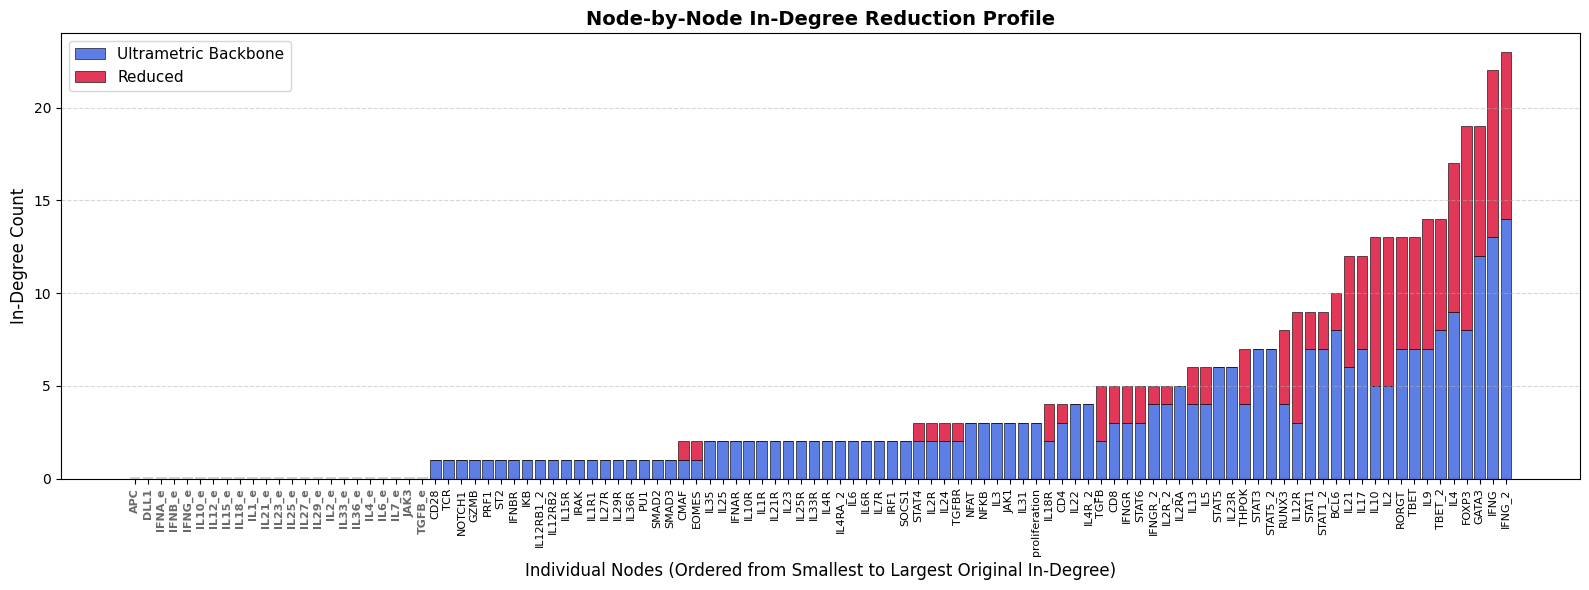

In [58]:
plot_node_degree_reduction_profile_v3(G, B2)